In [4]:
import os
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR  = "/content/drive/MyDrive/Derin_Ogrenme_Proje/temiz_veriler"
IMAGE_DIR = DATA_DIR
LABEL_CSV = os.path.join(DATA_DIR, "filtreli_etiketler.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ── 1. Import'lar ───────────────────────────────────────────
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [6]:
# ── 2. Cihaz ayarı ──────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


In [7]:
# ── 3. Sabitler ─────────────────────────────────────────────
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 15
LR          = 1e-4
SEED        = 42
CLASSES     = ["Infiltration", "Effusion", "Atelectasis"]
NUM_CLASSES = len(CLASSES)

torch.manual_seed(SEED)
np.random.seed(SEED)

In [8]:
# ── 4. Veri yolu ─────────────────────────────────────────────
# Colab'da Kaggle API ile veri indirme:
#
#   from google.colab import files
#   files.upload()  # kaggle.json yükleyin
#   !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
#   !kaggle datasets download -d nih-chest-xrays/data --unzip -p /content/chestxray

DATA_DIR  = "/content/chestxray"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
LABEL_CSV = os.path.join(DATA_DIR, "Data_Entry_2017.csv")


In [9]:
# ── 5. Etiket hazırlama ──────────────────────────────────────
def load_labels(csv_path, classes):
    df = pd.read_csv(csv_path)
    df = df[["Image Index", "Finding Labels"]].copy()

    for cls in classes:
        df[cls] = df["Finding Labels"].apply(lambda x: 1 if cls in x else 0)

    mask       = df[classes].sum(axis=1) > 0
    normal_mask = df["Finding Labels"] == "No Finding"
    df_pos  = df[mask]
    df_neg  = df[normal_mask].sample(
        n=min(len(df_pos), df[normal_mask].shape[0]), random_state=SEED
    )
    df_final = pd.concat([df_pos, df_neg]).reset_index(drop=True)

    print(f"Toplam örnek: {len(df_final)}")
    for cls in classes:
        print(f"  {cls}: {df_final[cls].sum()} pozitif")
    return df_final

In [10]:
# ── 6. Dataset sınıfı ────────────────────────────────────────
class ChestXrayDataset(Dataset):
    def __init__(self, df, image_dir, classes, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.classes   = classes
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["Image Index"])
        image    = Image.open(img_path).convert("L")  # Gri tonlamalı

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row[self.classes].values.astype(float), dtype=torch.float32
        )
        return image, label

In [11]:
# ── 7. Dönüşümler ────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [12]:
# ── 8. Train / Val / Test bölme ──────────────────────────────
def get_dataloaders(df, image_dir, classes):
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED)
    val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=SEED)

    train_ds = ChestXrayDataset(train_df, image_dir, classes, train_transform)
    val_ds   = ChestXrayDataset(val_df,   image_dir, classes, val_transform)
    test_ds  = ChestXrayDataset(test_df,  image_dir, classes, val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

In [ ]:
# ── 9. MODEL A — Naif (G,G,G kopyalama) ─────────────────────
class NaiveModel(nn.Module):
    """
    Tek kanallı gri görüntüyü 3 kanala kopyalar,
    ImageNet önceden eğitilmiş ResNet18 omurgasını kullanır.
    Tüm ağırlıklar serbest (fine-tune).
    """
    def __init__(self, num_classes):
        super().__init__()
        backbone    = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, num_classes)
        )
        self.backbone = backbone

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)   # [B,1,H,W] → [B,3,H,W]
        return self.backbone(x)

In [ ]:
# ── 10. MODEL B — Alan Uyarlama ──────────────────────────────
class AdaptationBlock(nn.Module):
    """Hafif CNN bloğu: 1 kanal → 3 kanal"""
    def __init__(self):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 3, kernel_size=1),
            nn.BatchNorm2d(3),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DomainAdaptationModel(nn.Module):
    """
    AdaptationBlock + donmuş ResNet18 omurgası.
    Yalnızca AdaptationBlock + son FC eğitilir.
    """
    def __init__(self, num_classes):
        super().__init__()
        self.adapt = AdaptationBlock()

        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        for param in backbone.parameters():
            param.requires_grad = False          # Omurgayı dondur

        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, num_classes)
        )
        for param in backbone.fc.parameters():
            param.requires_grad = True           # FC serbest

        self.backbone = backbone

    def forward(self, x):
        x = self.adapt(x)
        return self.backbone(x)

In [13]:
# ── 9. MODEL A — Naif (G,G,G kopyalama) — DenseNet121 ───────
class NaiveModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        in_features = backbone.classifier.in_features  # 1024
        backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, num_classes)
        )
        self.backbone = backbone

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)   # [B,1,H,W] → [B,3,H,W]
        return self.backbone(x)


# ── 10. MODEL B — Alan Uyarlama — DenseNet121 ────────────────
class AdaptationBlock(nn.Module):
    """Hafif CNN bloğu: 1 kanal → 3 kanal"""
    def __init__(self):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 3, kernel_size=1),
            nn.BatchNorm2d(3),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DomainAdaptationModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.adapt = AdaptationBlock()

        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

        # Omurgayı tamamen dondur
        for param in backbone.parameters():
            param.requires_grad = False

        in_features = backbone.classifier.in_features  # 1024
        backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, num_classes)
        )
        # FC katmanını serbest bırak
        for param in backbone.classifier.parameters():
            param.requires_grad = True

        self.backbone = backbone

    def forward(self, x):
        x = self.adapt(x)
        return self.backbone(x)

In [14]:
# ── 11. Eğitim fonksiyonu ────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)

In [15]:
# ── 12. Değerlendirme fonksiyonu ─────────────────────────────
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            all_probs.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)
    preds      = (all_probs >= 0.5).astype(int)

    auc_scores = [
        roc_auc_score(all_labels[:, i], all_probs[:, i])
        for i in range(all_labels.shape[1])
        if all_labels[:, i].sum() > 0
    ]
    mean_auc = np.mean(auc_scores)
    mean_f1  = f1_score(all_labels, preds, average="macro", zero_division=0)

    return total_loss / len(loader), mean_auc, mean_f1


In [16]:
# ── 13. Ana eğitim döngüsü ───────────────────────────────────
def train_model(model, train_loader, val_loader, model_name="model"):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler    = GradScaler()

    history  = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
    best_auc = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_auc, val_f1 = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        history["val_f1"].append(val_f1)

        print(f"[{model_name}] Epoch {epoch:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"AUC: {val_auc:.4f} | F1: {val_f1:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), f"best_{model_name}.pth")

    print(f"\n[{model_name}] En iyi Val AUC: {best_auc:.4f}")
    return history

In [17]:
# ── 14. Görselleştirme ───────────────────────────────────────
def plot_results(hist_naive, hist_adapt):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    epochs = range(1, NUM_EPOCHS + 1)

    for ax, key, title in zip(
        axes,
        ["val_loss", "val_auc", "val_f1"],
        ["Validation Loss", "Validation AUC-ROC", "Validation F1"]
    ):
        ax.plot(epochs, hist_naive[key], label="Naif (G,G,G)", marker="o")
        ax.plot(epochs, hist_adapt[key], label="Alan Uyarlama", marker="s")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.savefig("karsilastirma.png", dpi=150)
    plt.show()

In [18]:
# ── 15. Test değerlendirmesi ─────────────────────────────────
def test_model(model, test_loader, model_path, model_name):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    test_loss, test_auc, test_f1 = evaluate(model, test_loader, criterion)
    print(f"\n{'='*50}")
    print(f"[{model_name}] TEST SONUÇLARI")
    print(f"  Loss : {test_loss:.4f}")
    print(f"  AUC  : {test_auc:.4f}")
    print(f"  F1   : {test_f1:.4f}")
    print(f"{'='*50}")
    return test_auc, test_f1

In [20]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_DIR  = "/content/drive/MyDrive/Derin_Ogrenme_Proje/temiz_veriler"
IMAGE_DIR = DATA_DIR
LABEL_CSV = os.path.join(DATA_DIR, "filtreli_etiketler.csv")

Mounted at /content/drive


In [22]:
import pandas as pd
df_test = pd.read_csv("/content/drive/MyDrive/Derin_Ogrenme_Proje/temiz_veriler/filtreli_etiketler.csv")
print(df_test.shape)
print(df_test.head())

(44909, 12)
        Image Index         Finding Labels  Follow-up #  Patient ID  \
0  00000001_002.png  Cardiomegaly|Effusion            2           1   
1  00000003_003.png    Hernia|Infiltration            3           3   
2  00000004_000.png            Mass|Nodule            0           4   
3  00000005_006.png           Infiltration            6           5   
4  00000005_007.png  Effusion|Infiltration            7           5   

  Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0        058Y              M            PA                 2500     2048   
1        076Y              F            PA                 2698     2991   
2        082Y              M            AP                 2500     2048   
3        070Y              F            PA                 2992     2991   
4        070Y              F            PA                 2566     2681   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.168  0.168          NaN 

In [23]:
import os
DATA_DIR  = "/content/drive/MyDrive/Derin_Ogrenme_Proje/temiz_veriler"
IMAGE_DIR = DATA_DIR
LABEL_CSV = os.path.join(DATA_DIR, "filtreli_etiketler.csv")
print(LABEL_CSV)  # Doğru yol

/content/drive/MyDrive/Derin_Ogrenme_Proje/temiz_veriler/filtreli_etiketler.csv


Toplam örnek: 35430
  Infiltration: 19870 pozitif
  Effusion: 13307 pozitif
  Atelectasis: 11535 pozitif

>>> MODEL A: Naif (G,G,G) eğitimi başlıyor...

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 238MB/s]


[naive] Epoch 01/15 | Train Loss: 0.5799 | Val Loss: 0.5451 | AUC: 0.7711 | F1: 0.6231
[naive] Epoch 02/15 | Train Loss: 0.5419 | Val Loss: 0.5391 | AUC: 0.7809 | F1: 0.6430
[naive] Epoch 03/15 | Train Loss: 0.5287 | Val Loss: 0.5425 | AUC: 0.7827 | F1: 0.6256
[naive] Epoch 04/15 | Train Loss: 0.5176 | Val Loss: 0.5278 | AUC: 0.7950 | F1: 0.6382
[naive] Epoch 05/15 | Train Loss: 0.5043 | Val Loss: 0.5229 | AUC: 0.7969 | F1: 0.6472
[naive] Epoch 06/15 | Train Loss: 0.4933 | Val Loss: 0.5301 | AUC: 0.7927 | F1: 0.6507
[naive] Epoch 07/15 | Train Loss: 0.4761 | Val Loss: 0.5336 | AUC: 0.7972 | F1: 0.6556
[naive] Epoch 08/15 | Train Loss: 0.4560 | Val Loss: 0.5412 | AUC: 0.7946 | F1: 0.6724
[naive] Epoch 09/15 | Train Loss: 0.4307 | Val Loss: 0.5491 | AUC: 0.7929 | F1: 0.6661
[naive] Epoch 10/15 | Train Loss: 0.4057 | Val Loss: 0.5548 | AUC: 0.7889 | F1: 0.6677
[naive] Epoch 11/15 | Train Loss: 0.3736 | Val Loss: 0.5890 | AUC: 0.7874 | F1: 0.6624
[naive] Epoch 12/15 | Train Loss: 0.3492 | 

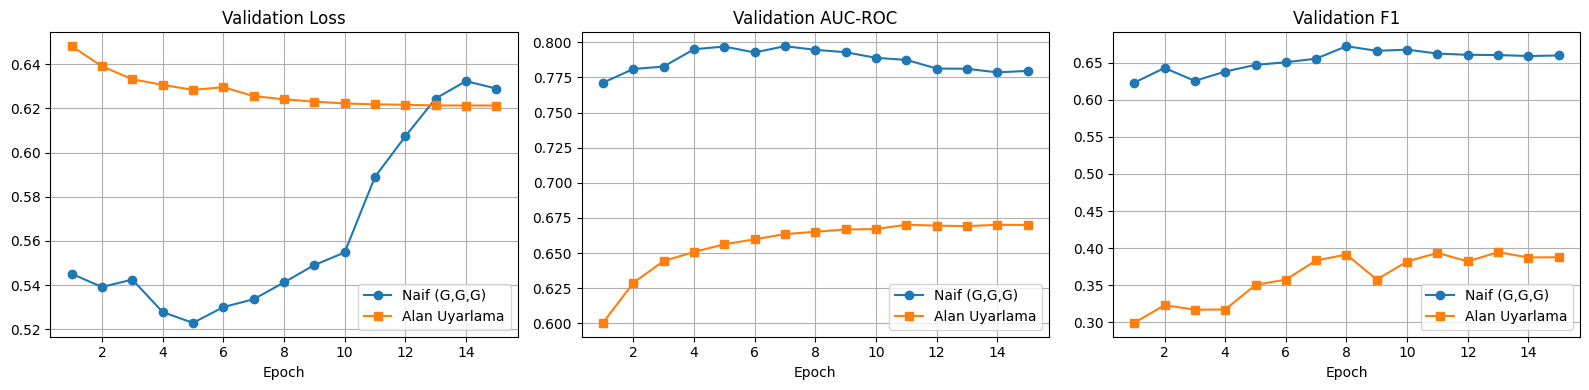


[Naif] TEST SONUÇLARI
  Loss : 0.5359
  AUC  : 0.7956
  F1   : 0.6545

[Alan Uyarlama] TEST SONUÇLARI
  Loss : 0.6225
  AUC  : 0.6673
  F1   : 0.3931


(np.float64(0.6672708834856979), 0.3930692102235675)

In [24]:
# ── 16. Ana akış ─────────────────────────────────────────────
# Veriyi yükle
df = load_labels(LABEL_CSV, CLASSES)
train_loader, val_loader, test_loader = get_dataloaders(df, IMAGE_DIR, CLASSES)

# Model A — Naif
print("\n>>> MODEL A: Naif (G,G,G) eğitimi başlıyor...\n")
naive_model = NaiveModel(NUM_CLASSES)
hist_naive  = train_model(naive_model, train_loader, val_loader, "naive")

# Model B — Alan Uyarlama
print("\n>>> MODEL B: Alan Uyarlama eğitimi başlıyor...\n")
adapt_model = DomainAdaptationModel(NUM_CLASSES)
hist_adapt  = train_model(adapt_model, train_loader, val_loader, "adapt")

# Grafik
plot_results(hist_naive, hist_adapt)

# Test
naive_model2 = NaiveModel(NUM_CLASSES)
adapt_model2 = DomainAdaptationModel(NUM_CLASSES)
test_model(naive_model2, test_loader, "best_naive.pth", "Naif")
test_model(adapt_model2, test_loader, "best_adapt.pth", "Alan Uyarlama")